In [2]:
# ============================================
# Political Tech Map (Partisan) — Setup Cell
# ============================================

# --- Install core libraries (run only once) ---
%pip install pandas numpy matplotlib seaborn openpyxl pillow

# --- Import essentials ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# --- Set pandas options for cleaner display ---
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# --- Define project directories ---
DATA_DIR = Path("data")
LOGO_DIR = Path("logos")
OUTPUT_DIR = Path("output")

# Create directories if not already present
for d in [DATA_DIR, LOGO_DIR, OUTPUT_DIR]:
    d.mkdir(exist_ok=True)

print("✅ Environment ready.")
print(f"Data folder: {DATA_DIR.resolve()}")


Note: you may need to restart the kernel to use updated packages.
✅ Environment ready.
Data folder: /Users/ujwalneethipudi/Documents/GitHub/PTS_Map/data


In [3]:
# ============================================
# Load dataset
# ============================================

df = pd.read_csv(DATA_DIR / "map_data.csv")
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Quick preview
display(df.head(5))


Loaded dataset with 201 rows and 11 columns.



,S. No.,Entity,Logo,HQ,Domain,Description,Map Bucket 1,Map Bucket 2,Relevance Flag (Y/N),Sub Bucket,Tools/Products
0,1,Panterra Global,NaN,United Kingdom,https://www.panterra.global/,Strategic advisory to governments/corporations...,Media & Messaging,NaN,Y,NaN,NaN
1,2,Palantir,NaN,United States,https://www.palantir.com/,"Large-scale data analytics & modelling, AI and...",Data Analytics and Modeling,NaN,N,NaN,NaN
2,3,influencethe.com,NaN,Bulgaria,https://influencethe.com/,Disinformation detection & “community intellig...,Media & Messaging,NaN,Y,Information Integrity / Disinformation,NaN
3,4,Electify,NaN,NaN,NaN,"Secure online election software; customizable,...",Voting Tech,NaN,Y,NaN,NaN
4,5,Genaios GmbH,NaN,Germany,https://genaios.ai/,"AI-powered fact-checking, content originality ...",Media & Messaging,NaN,Y,NaN,NaN


🔍 Distinct 'Map Bucket 1' categories found:



,map_bucket_1_raw,count
10,civic tech,1
13,civictech,1
14,community engagement,1
7,data analytics and modeling,7
8,fundraising,5
12,govtech,1
9,govtech / civic infrastructure,3
11,information integrity / disinformation,1
0,media & messaging,39
3,organisational infrastructure,16


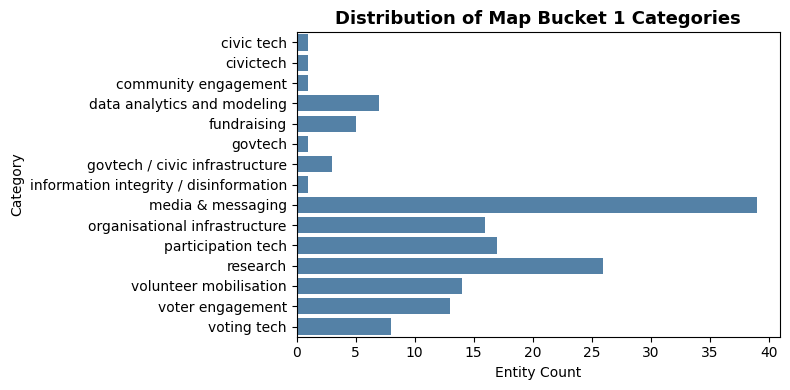


🗂 Clean list for schema design:

- Civic Tech
- Civictech
- Community Engagement
- Data Analytics And Modeling
- Fundraising
- Govtech
- Govtech / Civic Infrastructure
- Information Integrity / Disinformation
- Media & Messaging
- Organisational Infrastructure
- Participation Tech
- Research
- Volunteer Mobilisation
- Voter Engagement
- Voting Tech


In [4]:
# ============================================
# Explore "Map Bucket 1" categories
# ============================================

# Keep only non-empty values
bucket_series = df['Map Bucket 1'].dropna().astype(str).str.strip()

# Count unique categories (case-insensitive)
bucket_counts = (
    bucket_series.str.lower()
    .value_counts()
    .rename_axis("map_bucket_1_raw")
    .reset_index(name="count")
    .sort_values("map_bucket_1_raw")
)

print("🔍 Distinct 'Map Bucket 1' categories found:\n")
display(bucket_counts)

# Optional: visualize distribution
plt.figure(figsize=(8, 4))
sns.barplot(y="map_bucket_1_raw", x="count", data=bucket_counts, color="steelblue")
plt.title("Distribution of Map Bucket 1 Categories", fontsize=13, weight="bold")
plt.xlabel("Entity Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Create a clean list (title-cased) for manual schema refinement
clean_list = sorted(bucket_series.str.strip().drop_duplicates().str.title())
print("\n🗂 Clean list for schema design:\n")
for cat in clean_list:
    print("-", cat)


In [5]:
# ==============================================================
# Step 1: Canonical Mapping for "Map Bucket 1" categories
# ==============================================================

# Mapping of raw categories → canonical buckets
canonical_map = {
    # Messaging & Media
    "media & messaging": "Messaging & Media",
    "information integrity / disinformation": "Messaging & Media",

    # Data Analytics & Modeling
    "data analytics and modeling": "Data Analytics & Modeling",

    # Research & Insights
    "research": "Research & Insights",

    # Engagement & Mobilisation
    "voter engagement": "Engagement & Mobilisation",
    "volunteer mobilisation": "Engagement & Mobilisation",
    "community engagement": "Engagement & Mobilisation",
    "participation tech": "Engagement & Mobilisation",

    # Fundraising
    "fundraising": "Fundraising",

    # Voting Tech
    "voting tech": "Voting Tech",

    # GovTech / Civic Infrastructure
    "govtech": "GovTech / Civic Infrastructure",
    "govtech / civic infrastructure": "GovTech / Civic Infrastructure",
    "civic tech": "GovTech / Civic Infrastructure",
    "civictech": "GovTech / Civic Infrastructure",

    # Movement-Wide & Org Infrastructure
    "organisational infrastructure": "Movement-Wide & Organisational Infrastructure",
}

# Normalize and map
df["Map Bucket 1 (Normalized)"] = (
    df["Map Bucket 1"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(canonical_map)
)

# Check mapping coverage
print("✅ Canonicalization complete.")
print(df["Map Bucket 1 (Normalized)"].value_counts(dropna=False))


✅ Canonicalization complete.
Map Bucket 1 (Normalized)
NaN                                              48
Engagement & Mobilisation                        45
Messaging & Media                                40
Research & Insights                              26
Movement-Wide & Organisational Infrastructure    16
Voting Tech                                       8
Data Analytics & Modeling                         7
GovTech / Civic Infrastructure                    6
Fundraising                                       5
Name: count, dtype: int64


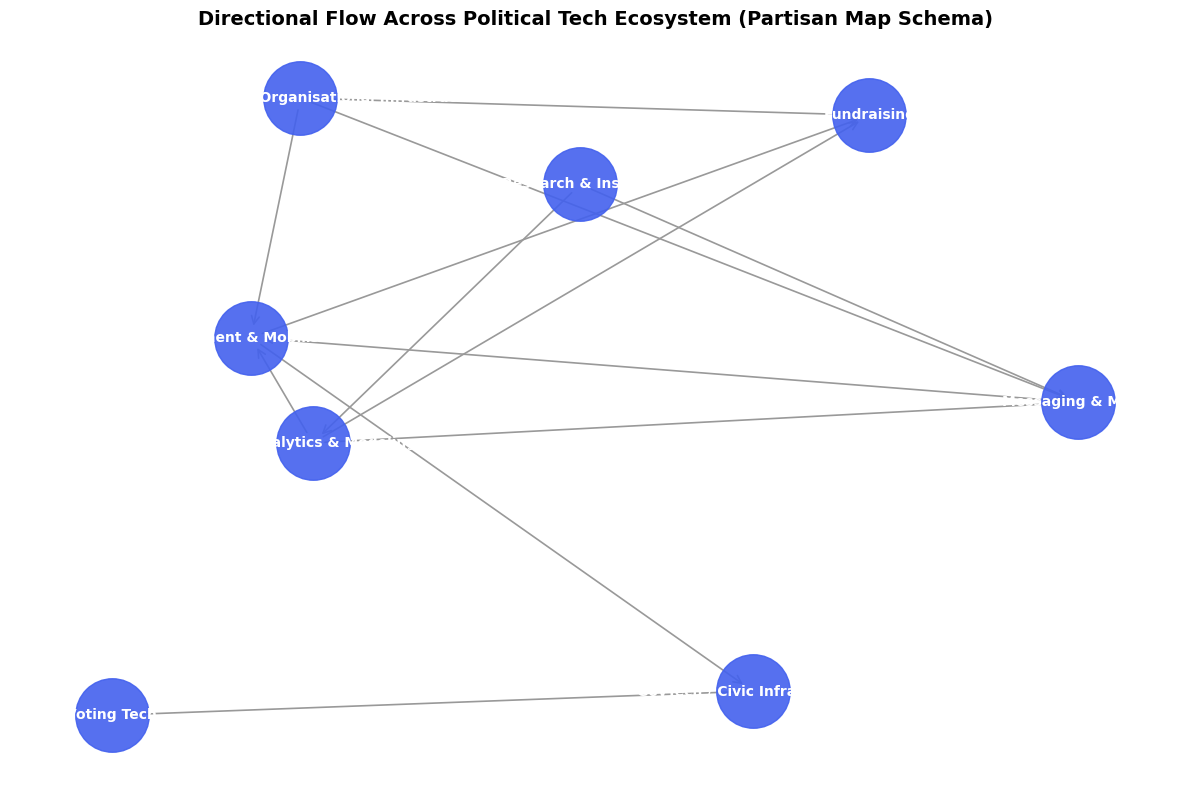

In [6]:
# ==============================================================
# Step 2: Directional flow between canonical categories
# ==============================================================

import matplotlib.pyplot as plt
import networkx as nx

# Define directional relationships (edges)
edges = [
    ("Research & Insights", "Messaging & Media"),
    ("Research & Insights", "Data Analytics & Modeling"),
    ("Data Analytics & Modeling", "Messaging & Media"),
    ("Data Analytics & Modeling", "Engagement & Mobilisation"),
    ("Data Analytics & Modeling", "Fundraising"),
    ("Messaging & Media", "Engagement & Mobilisation"),
    ("Engagement & Mobilisation", "Fundraising"),
    ("Movement-Wide & Organisational Infrastructure", "Messaging & Media"),
    ("Movement-Wide & Organisational Infrastructure", "Engagement & Mobilisation"),
    ("Movement-Wide & Organisational Infrastructure", "Fundraising"),
    ("GovTech / Civic Infrastructure", "Voting Tech"),
    ("Engagement & Mobilisation", "GovTech / Civic Infrastructure"),
]

# Create graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Define layout (left to right flow)
pos = nx.spring_layout(G, seed=42, k=1.5)

# Draw
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_color="#4361EE", node_size=2800, alpha=0.9)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=14, edge_color="#999999", width=1.2)
nx.draw_networkx_labels(G, pos, font_size=10, font_color="white", font_weight="bold")
plt.title("Directional Flow Across Political Tech Ecosystem (Partisan Map Schema)", fontsize=14, weight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()


✅ Summary of validated (Y) entities by canonical category:



,Canonical Category,Entity Count
5,Data Analytics & Modeling,4
0,Engagement & Mobilisation,28
6,Fundraising,4
7,GovTech / Civic Infrastructure,3
1,Messaging & Media,26
4,Movement-Wide & Organisational Infrastructure,4
2,Research & Insights,17
3,Voting Tech,8


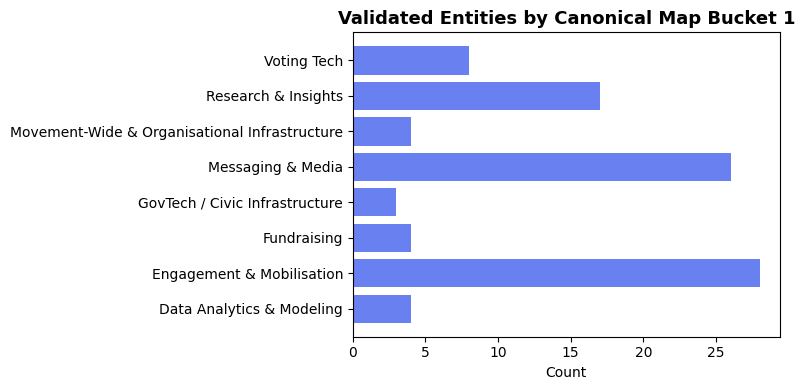

💾 Exported demo subset → /Users/ujwalneethipudi/Documents/GitHub/PTS_Map/data/map_data_demo.csv


In [7]:
# ==============================================================
# Step 3: Summarize normalized schema and export demo subset
# ==============================================================

# --- Keep only relevant rows ---
df_demo = df[df["Relevance Flag (Y/N)"].astype(str).str.strip().str.upper().eq("Y")].copy()

# --- Count entities by normalized bucket ---
summary = (
    df_demo["Map Bucket 1 (Normalized)"]
    .value_counts(dropna=False)
    .rename_axis("Canonical Category")
    .reset_index(name="Entity Count")
    .sort_values("Canonical Category")
)

print("✅ Summary of validated (Y) entities by canonical category:\n")
display(summary)

# --- Optional: bar chart for quick visual sanity check ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(summary["Canonical Category"], summary["Entity Count"], color="#4361EE", alpha=0.8)
plt.title("Validated Entities by Canonical Map Bucket 1", fontsize=13, weight="bold")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# --- Export filtered dataset for demo ---
demo_path = DATA_DIR / "map_data_demo.csv"
df_demo.to_csv(demo_path, index=False)
print(f"💾 Exported demo subset → {demo_path.resolve()}")


In [8]:
# ============================================
# Poster v0 — placeholder logos (Pakflatt.jpeg)
# ============================================
from pathlib import Path
import math
import pandas as pd
from PIL import Image, ImageDraw, ImageFont

DATA_DIR = Path("data")
LOGO_DIR = Path("logos")
OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# --- Load data (prefer the filtered demo if present) ---
csv_path = DATA_DIR / "map_data_demo.csv"
if not csv_path.exists():
    csv_path = DATA_DIR / "map_data.csv"

df = pd.read_csv(csv_path)

# If normalized column missing, create quick mapping inline (same as earlier plan)
if "Map Bucket 1 (Normalized)" not in df.columns:
    canonical_map = {
        "media & messaging": "Messaging & Media",
        "information integrity / disinformation": "Messaging & Media",
        "data analytics and modeling": "Data Analytics & Modeling",
        "research": "Research & Insights",
        "voter engagement": "Engagement & Mobilisation",
        "volunteer mobilisation": "Engagement & Mobilisation",
        "community engagement": "Engagement & Mobilisation",
        "participation tech": "Engagement & Mobilisation",
        "fundraising": "Fundraising",
        "voting tech": "Voting Tech",
        "govtech": "GovTech / Civic Infrastructure",
        "govtech / civic infrastructure": "GovTech / Civic Infrastructure",
        "civic tech": "GovTech / Civic Infrastructure",
        "civictech": "GovTech / Civic Infrastructure",
        "organisational infrastructure": "Movement-Wide & Organisational Infrastructure",
    }
    df["Map Bucket 1 (Normalized)"] = (
        df["Map Bucket 1"]
        .astype(str).str.strip().str.lower()
        .map(canonical_map)
    )

# If Relevance column exists, filter to Y for poster realism
if "Relevance Flag (Y/N)" in df.columns:
    df = df[df["Relevance Flag (Y/N)"].astype(str).str.strip().str.upper().eq("Y")]

# --- Canonical bucket order for the 2x4 grid ---
buckets = [
    "Messaging & Media",
    "Engagement & Mobilisation",
    "Fundraising",
    "Research & Insights",
    "Data Analytics & Modeling",
    "GovTech / Civic Infrastructure",
    "Voting Tech",
    "Movement-Wide & Organisational Infrastructure",
]

# --- Choose how many logos per cell for this wireframe ---
MAX_PER_CELL = 8  # tweak 6–10 to taste

# --- Prepare per-bucket entity lists (we only need counts for layout) ---
by_bucket = {b: [] for b in buckets}
if "Map Bucket 1 (Normalized)" in df.columns:
    for b in buckets:
        names = (
            df.loc[df["Map Bucket 1 (Normalized)"].eq(b), "Entity"]
            .dropna().astype(str).tolist()
        )
        # pad with dummy names if empty so we still see placement
        if not names:
            names = [f"{b} org {i+1}" for i in range(MAX_PER_CELL)]
        by_bucket[b] = names[:MAX_PER_CELL]
else:
    # Fallback if normalization failed: put dummies so you can still see grid
    for b in buckets:
        by_bucket[b] = [f"{b} org {i+1}" for i in range(MAX_PER_CELL)]

# --- Canvas: A3 landscape at 300DPI → 4961 x 3508 px ---
W, H = 4961, 3508
bg = Image.new("RGB", (W, H), "white")
draw = ImageDraw.Draw(bg)

# Try to load a system font; fallback to default
def try_font(size):
    for f in ["arial.ttf", "DejaVuSans.ttf"]:
        try:
            return ImageFont.truetype(f, size)
        except:
            continue
    return ImageFont.load_default()

TITLE_FONT = try_font(96)
HEAD_FONT  = try_font(52)
SMALL_FONT = try_font(28)

# --- Title & subtitle ---
title = "European Political Tech Landscape (Prototype)"
subtitle = "Map Bucket 1 demo · placeholder logos · Partisan · Nov 2025"
tw, th = draw.textbbox((0,0), title, font=TITLE_FONT)[2:]
sw, sh = draw.textbbox((0,0), subtitle, font=SMALL_FONT)[2:]
draw.text(((W-tw)/2, 80), title, fill="black", font=TITLE_FONT)
draw.text(((W-sw)/2, 80+th+10), subtitle, fill="black", font=SMALL_FONT)

# --- Grid geometry (2 rows x 4 cols) ---
top_margin   = 80 + th + sh + 60
side_margin  = 160
bottom_margin= 140
cols, rows   = 4, 2
gutter_x     = 40
gutter_y     = 40

cell_w = (W - 2*side_margin - (cols-1)*gutter_x) // cols
cell_h = (H - top_margin - bottom_margin - (rows-1)*gutter_y) // rows

# --- Placeholder logo ---
placeholder_path = LOGO_DIR / "Pakflatt.jpeg"
if placeholder_path.exists():
    base_logo = Image.open(placeholder_path).convert("RGBA")
else:
    # create a simple placeholder tile
    base_logo = Image.new("RGBA", (600, 300), (230,230,230,255))
    d = ImageDraw.Draw(base_logo)
    msg = "LOGO"
    mw, mh = d.textbbox((0,0), msg, font=HEAD_FONT)[2:]
    d.text(((600-mw)/2, (300-mh)/2), msg, fill="black", font=HEAD_FONT)

def paste_logo(tile, target_box):
    """Resize base_logo into target_box (w,h) preserving aspect ratio and paste centered."""
    w, h = target_box
    logo = base_logo.copy()
    lw, lh = logo.size
    scale = min(w/lw, h/lh)
    new_size = (max(1, int(lw*scale)), max(1, int(lh*scale)))
    logo = logo.resize(new_size, Image.LANCZOS)
    return logo

# --- Draw each cell with header + repeated logos ---
for idx, bucket in enumerate(buckets):
    r = idx // cols
    c = idx % cols
    x0 = side_margin + c*(cell_w + gutter_x)
    y0 = top_margin  + r*(cell_h + gutter_y)
    x1 = x0 + cell_w
    y1 = y0 + cell_h

    # Box border
    draw.rounded_rectangle([x0, y0, x1, y1], radius=24, outline="black", width=3)

    # Header
    hb = draw.textbbox((0,0), bucket, font=HEAD_FONT)
    draw.text((x0+28, y0+20), bucket, fill="black", font=HEAD_FONT)

    # Logo grid inside the box
    inner_top = y0 + 20 + (hb[3]-hb[1]) + 20
    inner_left = x0 + 24
    inner_right = x1 - 24
    inner_bottom = y1 - 24

    inner_w = inner_right - inner_left
    inner_h = inner_bottom - inner_top

    # Decide a logo grid (cols x rows) based on MAX_PER_CELL
    lg_cols = 4 if MAX_PER_CELL >= 8 else 3
    lg_rows = math.ceil(MAX_PER_CELL / lg_cols)
    # compute cell size for logos
    lg_gx, lg_gy = 20, 16
    logo_w = (inner_w - (lg_cols-1)*lg_gx) // lg_cols
    logo_h = (inner_h - (lg_rows-1)*lg_gy) // lg_rows

    items = by_bucket[bucket]
    for i, _name in enumerate(items):
        rr = i // lg_cols
        cc = i % lg_cols
        lx = inner_left + cc*(logo_w + lg_gx)
        ly = inner_top  + rr*(logo_h + lg_gy)

        logo = paste_logo(base_logo, (logo_w, logo_h))
        lw, lh = logo.size
        paste_x = lx + (logo_w - lw)//2
        paste_y = ly + (logo_h - lh)//2
        bg.paste(logo, (paste_x, paste_y), logo)

# --- Save outputs ---
png_path = OUT_DIR / "poster_v0.png"
pdf_path = OUT_DIR / "poster_v0.pdf"
bg.save(png_path)
bg.convert("RGB").save(pdf_path, "PDF", resolution=300.0)
print(f"✅ Poster v0 exported:\n- {png_path.resolve()}\n- {pdf_path.resolve()}")


✅ Poster v0 exported:
- /Users/ujwalneethipudi/Documents/GitHub/PTS_Map/output/poster_v0.png
- /Users/ujwalneethipudi/Documents/GitHub/PTS_Map/output/poster_v0.pdf
